In [ ]:
import re
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from urllib.robotparser import RobotFileParser

URL = "https://en.wikipedia.org/wiki/List_of_best-selling_books"
HEADERS = {"User-Agent": "a_yessenzhanuly@kbtu.kz"}


robots = requests.get("https://en.wikipedia.org/robots.txt", headers=HEADERS, timeout=30)
rp = RobotFileParser()
rp.parse(robots.text.splitlines())
print("robots.txt status:", robots.status_code)
print("Scraping allowed for this URL:", rp.can_fetch(HEADERS["User-Agent"], URL))

robots.txt status: 200
Scraping allowed for this URL: True


In [2]:

response = requests.get(URL, headers=HEADERS, timeout=30)
print("Status code:", response.status_code)
response.raise_for_status()

soup = BeautifulSoup(response.text, "html.parser")
tables = soup.find_all("table", class_="wikitable")
print("Number of wikitables on the page:", len(tables))

Status code: 200
Number of wikitables on the page: 14


In [3]:
def cell_text(cell):
    """Return clean text of a table cell (without footnote <sup> tags)."""
    for sup in cell.find_all("sup"):
        sup.decompose()
    return re.sub(r"\s+", " ", cell.get_text()).strip()

rows = []
used_tables = 0

for table in tables:
    header_cells = table.find("tr").find_all("th")
    headers = [cell_text(th) for th in header_cells]

    
    if not headers or headers[0] != "Book" or "Genre" not in headers:
        continue
    used_tables += 1

    for tr in table.find_all("tr")[1:]:         
        cells = tr.find_all(["td", "th"])
        if len(cells) != 6:                     
            continue
        title, author, language, year, sales, genre = [cell_text(c) for c in cells]
        rows.append({
            "title": title,
            "authors": author,
            "language": language,
            "first_published": year,
            "sales_text": sales,
            "genre_raw": genre,
        })

print("Tables used:", used_tables)
raw_df = pd.DataFrame(rows)
raw_df.to_csv("books_scraped_raw.csv", index=False)
print("Raw shape:", raw_df.shape)
raw_df.head(10)

Tables used: 4
Raw shape: (169, 6)


,title,authors,language,first_published,sales_text,genre_raw
0,A Tale of Two Cities,Charles Dickens,English,1859,>200 million,Historical fiction
1,The Little Prince (Le Petit Prince),Antoine de Saint-Exupéry,French,1943,200 million,Fantasy
2,The Alchemist (O Alquimista),Paulo Coelho,Portuguese,1988,150 million,Fantasy
3,Harry Potter and the Philosopher's Stone,J. K. Rowling,English,1997,120 million,Fantasy
4,And Then There Were None,Agatha Christie,English,1939,100 million,Mystery
5,Dream of the Red Chamber (紅樓夢),Cao Xueqin,Chinese,1791,100 million,Family saga
6,The Hobbit,J. R. R. Tolkien,English,1937,100 million,"Fantasy, children's fiction"
7,Alice's Adventures in Wonderland,Lewis Carroll,English,1865,100 million,"Fantasy, absurdist fiction"
8,She: A History of Adventure,H. Rider Haggard,English,1887,83 million,Adventure
9,The Da Vinci Code,Dan Brown,English,2003,80 million,Mystery thriller


In [4]:
df = raw_df.copy()


df = df.replace("", np.nan)


df["title"] = df["title"].str.replace(r"\s*\(.*?\)", "", regex=True).str.strip()
df["title_clean"] = (df["title"].str.lower()
                                .str.replace(r"[^\w\s]", "", regex=True)
                                .str.replace(r"\s+", " ", regex=True)
                                .str.strip())


df["author"] = df["authors"].str.split(r",| and ", regex=True).str[0].str.strip()
df = df.drop(columns="authors")


df["publication_year"] = pd.to_numeric(df["first_published"].str.extract(r"(\d{4})")[0], errors="coerce")
df = df.drop(columns="first_published")


df["sales_millions"] = pd.to_numeric(df["sales_text"].str.extract(r"(\d+(?:\.\d+)?)")[0], errors="coerce")


df["wiki_genre"] = df["genre_raw"].str.split(",").str[0].str.strip().str.lower()


print("Duplicate title+author:", df.duplicated(subset=["title_clean", "author"]).sum())
df = df.drop_duplicates(subset=["title_clean", "author"])

before = len(df)
df = df.dropna(subset=["title", "publication_year", "sales_millions"])
print("Rows dropped for missing title/year/sales:", before - len(df))

df["publication_year"] = df["publication_year"].astype(int)
df["decade"] = (df["publication_year"] // 10) * 10

df = df[["title", "title_clean", "author", "language", "publication_year", "decade",
         "sales_millions", "wiki_genre", "genre_raw", "sales_text"]].reset_index(drop=True)

df.to_csv("books_scraped_clean.csv", index=False)
print("Saved books_scraped_clean.csv with", len(df), "rows")
print()
print(df.dtypes)
print()
print("Missing values:")
print(df.isna().sum())
df.head(10)

Duplicate title+author: 0
Rows dropped for missing title/year/sales: 0
Saved books_scraped_clean.csv with 169 rows

title                object
title_clean          object
author               object
language             object
publication_year      int64
decade                int64
sales_millions      float64
wiki_genre           object
genre_raw            object
sales_text           object
dtype: object

Missing values:
title                0
title_clean          0
author               0
language             0
publication_year     0
decade               0
sales_millions       0
wiki_genre          44
genre_raw           44
sales_text           0
dtype: int64


,title,title_clean,author,language,publication_year,decade,sales_millions,wiki_genre,genre_raw,sales_text
0,A Tale of Two Cities,a tale of two cities,Charles Dickens,English,1859,1850,200.0,historical fiction,Historical fiction,>200 million
1,The Little Prince,the little prince,Antoine de Saint-Exupéry,French,1943,1940,200.0,fantasy,Fantasy,200 million
2,The Alchemist,the alchemist,Paulo Coelho,Portuguese,1988,1980,150.0,fantasy,Fantasy,150 million
3,Harry Potter and the Philosopher's Stone,harry potter and the philosophers stone,J. K. Rowling,English,1997,1990,120.0,fantasy,Fantasy,120 million
4,And Then There Were None,and then there were none,Agatha Christie,English,1939,1930,100.0,mystery,Mystery,100 million
5,Dream of the Red Chamber,dream of the red chamber,Cao Xueqin,Chinese,1791,1790,100.0,family saga,Family saga,100 million
6,The Hobbit,the hobbit,J. R. R. Tolkien,English,1937,1930,100.0,fantasy,"Fantasy, children's fiction",100 million
7,Alice's Adventures in Wonderland,alices adventures in wonderland,Lewis Carroll,English,1865,1860,100.0,fantasy,"Fantasy, absurdist fiction",100 million
8,She: A History of Adventure,she a history of adventure,H. Rider Haggard,English,1887,1880,83.0,adventure,Adventure,83 million
9,The Da Vinci Code,the da vinci code,Dan Brown,English,2003,2000,80.0,mystery thriller,Mystery thriller,80 million


In [5]:
df[["publication_year", "sales_millions"]].describe()

,publication_year,sales_millions
count,169.000000,169.000000
mean,1961.769231,29.184024
std,65.609959,29.169193
min,1304.000000,10.000000
25%,1947.000000,12.000000
50%,1974.000000,20.000000
75%,1995.000000,35.000000
max,2018.000000,200.000000


## top 10 best selling books

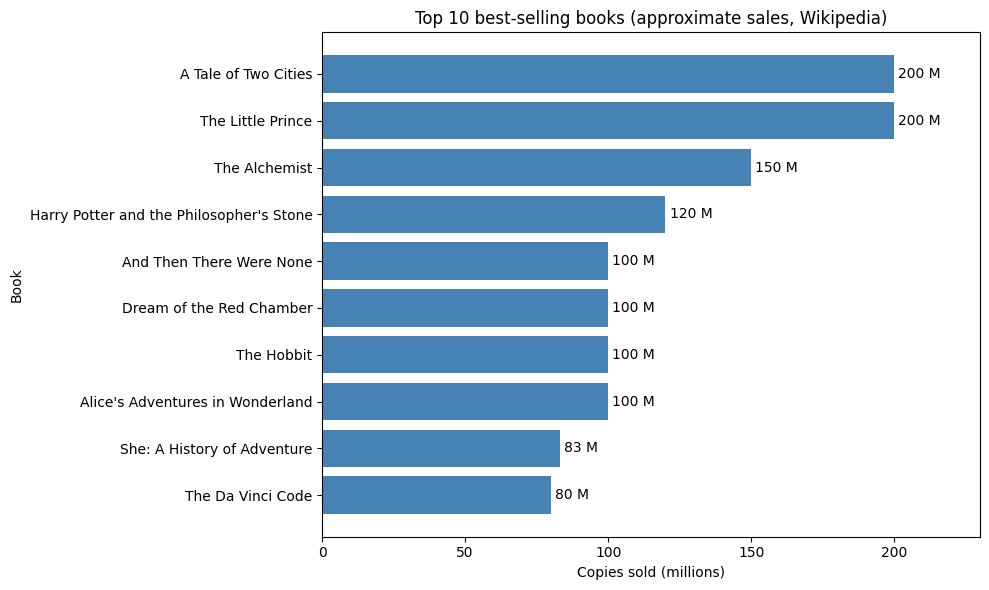

In [6]:
top10 = df.nlargest(10, "sales_millions").sort_values("sales_millions")   # sorted so the biggest bar is on top

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10["title"], top10["sales_millions"], color="steelblue")
ax.bar_label(bars, fmt="%.0f M", padding=3)

ax.set_title("Top 10 best-selling books (approximate sales, Wikipedia)")
ax.set_xlabel("Copies sold (millions)")
ax.set_ylabel("Book")
ax.set_xlim(0, top10["sales_millions"].max() * 1.15)
plt.tight_layout()
plt.savefig("top10_sales.png", dpi=150)
plt.show()